In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import joblib

import sbmlcore
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import recall_score,  roc_auc_score,  roc_curve
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.base import BaseEstimator, TransformerMixin

/Users/viktoriabrunner/Documents/Studium/PhD/thesis_submission/thesis_repository/.venv/lib/python3.11/site-packages/MDAnalysis/topology/TPRParser.py:161: DeprecationWarning: 'xdrlib' is deprecated and slated for removal in Python 3.13
  import xdrlib


In [2]:
data = pd.read_csv('data/ML_DATA_LEV.csv')
data.dropna(inplace= True)

#remove line below to train on samples rather than mutations
data.drop_duplicates(subset=['GENE_MUTATION'], keep='first', inplace=True)
data.GENE_MUTATION.value_counts()

GENE_MUTATION
gyrA_A90V     1
gyrB_K668R    1
gyrA_T164M    1
gyrA_Y379C    1
gyrB_G589V    1
             ..
gyrA_D488A    1
gyrA_P119L    1
gyrA_G477E    1
gyrB_A643D    1
gyrA_D94V     1
Name: count, Length: 163, dtype: int64

In [3]:
features = ['d_volume', 'd_hydropathy_KD', 'd_hydropathy_WW',
       'd_MW', 'd_Pi', 'secondary_structure', 'phi', 'psi', 'residue_sasa', 
       'n_hbond_acceptors', 'n_hbond_donors', 'SASA', 'snap2_score', 'dist_MGB', 'dist_MGE', 'dist_drug', 'temp_factor', 'depth', 'deep_ddG'] # 'B', 'C', 'E', 'G', 'H', 'T',

features = data[features]
features['secondary_structure_codes'] = pd.Categorical(features.secondary_structure, categories=features.secondary_structure.unique()).codes
features.drop('secondary_structure', inplace = True, axis = 1)

/var/folders/_3/8y_dwngx2614_y_52fzh1c4w0000gn/T/ipykernel_19429/812203343.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features['secondary_structure_codes'] = pd.Categorical(features.secondary_structure, categories=features.secondary_structure.unique()).codes
/var/folders/_3/8y_dwngx2614_y_52fzh1c4w0000gn/T/ipykernel_19429/812203343.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features.drop('secondary_structure', inplace = True, axis = 1)


In [4]:
features

,d_volume,d_hydropathy_KD,d_hydropathy_WW,d_MW,d_Pi,phi,psi,residue_sasa,n_hbond_acceptors,n_hbond_donors,SASA,snap2_score,dist_MGB,dist_MGE,dist_drug,temp_factor,depth,deep_ddG,secondary_structure_codes
0,51.4,2.4,-0.86,28.0,-0.04,-61.83,-59.76,47.0,2.0,0.0,55.555816,-64.0,14.254302,5.504266,10.310827,40.439999,1.665078,0.089,0
1,82.5,2.2,-2.18,48.1,2.89,-58.04,-41.61,97.4,1.0,1.0,88.155089,81.0,18.193078,7.778979,14.095746,46.660000,1.733342,-0.376,0
2,3.0,0.0,-1.98,-1.0,2.64,-58.04,-41.61,97.4,1.0,1.0,88.155089,56.0,18.193078,7.778979,14.095746,46.660000,1.733342,-0.347,0
3,-3.0,0.0,1.98,1.0,-2.64,-66.66,120.50,43.0,2.0,2.0,40.444768,53.0,21.565351,18.549803,13.333886,62.860001,2.030527,-0.309,1
4,-25.1,2.7,-0.10,-27.0,0.27,-78.75,123.63,5.4,2.0,0.0,3.978588,-22.0,38.286533,31.644022,37.267766,50.119999,3.114263,-1.229,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1623,-50.6,-5.2,0.92,-12.1,-0.42,-130.11,149.27,24.8,0.0,0.0,25.392934,-40.0,27.224609,38.799515,38.672577,96.040001,1.915598,-1.102,5
1628,-64.9,7.0,-0.78,-53.0,-5.69,-58.30,-53.31,99.4,1.0,1.0,108.315927,-17.0,43.646112,41.821476,47.286371,59.320000,1.914005,-0.669,0
1656,-113.3,4.1,0.14,-99.1,-4.79,-79.33,120.91,123.9,1.0,0.0,117.789422,25.0,39.778686,31.598502,35.352796,61.540001,1.769443,-1.407,3
1706,-54.5,0.4,-1.38,-14.1,-4.33,-96.55,-13.55,131.0,0.0,1.0,129.497644,-54.0,29.899138,38.862500,33.061004,91.370003,1.615220,-0.314,4


In [5]:
y = data['CLEAN_BINARY_PHENOTYPE'].map({'S':0, 'R':1})
y

0       1
1       1
2       1
3       1
4       0
       ..
1623    0
1628    0
1656    0
1706    0
1717    1
Name: CLEAN_BINARY_PHENOTYPE, Length: 163, dtype: int64

In [6]:
random_state=42
mutations ={}

df = data
mutations['tt'] = df.GENE_MUTATION
features = features
labels = df['CLEAN_BINARY_PHENOTYPE'].map({'S':0, 'R':1})
df['CLEAN_BINARY_PHENOTYPE'].value_counts()

CLEAN_BINARY_PHENOTYPE
S    138
R     25
Name: count, dtype: int64

In [7]:
mutations_train, mutations_test, X_train, X_test, Y_train, Y_test = train_test_split(mutations['tt'], features, labels, test_size=0.3,
                                                    random_state=random_state)
class DataFrameSelector(BaseEstimator, TransformerMixin):
    def __init__(self, attribute_names):
        self.attribute_names = attribute_names
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X[self.attribute_names].values

numerical_attribs = list(features)
numerical_attribs
headings = '\n'.join(i for i in numerical_attribs)

# Feature name mapping for better readability
feature_name_mapping = {'d_volume': 'Δ Volume', 'd_hydropathy_KD': 'Δ Hydropathy (Kyte-Doolittle)',
       'd_hydropathy_WW': 'Δ Hydropathy (White-Wimley)',
       'd_MW': 'Δ Molecular Weight', 'd_Pi': 'Δ Isoelectric Point',
       'phi': 'φ Angle', 'psi': 'ψ Angle',
       'residue_sasa': 'Residue SASA', 'n_hbond_acceptors': 'Number of H-Bond Acceptors',
       'n_hbond_donors': 'Number of H-Bond Donors', 'SASA': 'SASA', 'snap2_score': 'SNAP2 Score',
       'dist_MGB': 'Distance to second Mg²⁺ Ion', 'dist_MGE': 'Distance to first Mg²⁺ Ion',
       'dist_drug': 'Distance to Drug', 'temp_factor': 'Temperature Factor',
       'depth': 'Depth', 'deep_ddG': 'DeepDDG', 'secondary_structure_codes': 'Secondary Structure'}

numerical_attribs

['d_volume',
 'd_hydropathy_KD',
 'd_hydropathy_WW',
 'd_MW',
 'd_Pi',
 'phi',
 'psi',
 'residue_sasa',
 'n_hbond_acceptors',
 'n_hbond_donors',
 'SASA',
 'snap2_score',
 'dist_MGB',
 'dist_MGE',
 'dist_drug',
 'temp_factor',
 'depth',
 'deep_ddG',
 'secondary_structure_codes']

In [8]:
pipe = Pipeline([
    ('selector', DataFrameSelector(numerical_attribs)),
    ('scaling', RobustScaler())
    ])

X_train = pipe.fit_transform(X_train)    
Y_train = Y_train.squeeze().to_numpy()
Z_train = mutations_train.to_numpy()

# let's save the pipeline to preserve the scaling etc
joblib.dump(pipe, 'data/pipeline.pkl')

X_test = pipe.transform(X_test)
Y_test = Y_test.squeeze().to_numpy()   
Z_test = mutations_test.to_numpy()
print(len(X_train), len(Y_train), len(Z_train))
print(len(X_test), len(Y_test), len(Z_test))

114 114 114
49 49 49


In [9]:
model_logistic_regression = LogisticRegression()

In [10]:
fpr = {}
tpr = {}
auc = {}  # Renamed from 'roc' to 'auc' for clarity
recall = {}

rows={}
rows['feature'] = []
rows['auc'] = []  # Renamed from 'roc' to 'auc' for clarity

Y_train_prepared = Y_train
X_train_prepared = X_train

for i in range(len(numerical_attribs)):

    attribute = numerical_attribs[i].rstrip()

    model_logistic_regression.fit(X_train_prepared[:,i:i+1], Y_train_prepared)

    Y_probs = cross_val_predict(model_logistic_regression, X_train_prepared[:,i:i+1], Y_train_prepared, cv=3, method='predict_proba', n_jobs=-1)
    
    Y_scores = Y_probs[:,1]

    # mask = (Y_scores>0.6) | (Y_scores<0.4)

    fpr[attribute], tpr[attribute], thresholds = roc_curve(Y_train_prepared, Y_scores)

    auc[attribute] = roc_auc_score(Y_train_prepared, Y_scores)  # This IS the AUC value

    Y_train_predicted = model_logistic_regression.predict(X_train_prepared[:,i:i+1])

    recall[attribute] = recall_score(Y_train_prepared, Y_train_predicted)

    rows['auc'].append(auc[attribute])  # Storing AUC values
    # Use mapped name if available, otherwise use original name
    display_name = feature_name_mapping.get(attribute, attribute)
    rows['feature'].append(display_name)

    
df = pd.DataFrame(rows)
df.sort_values(by='auc', ascending=True, inplace=True)  # Sorting by AUC
df

,feature,auc
1,Δ Hydropathy (Kyte-Doolittle),0.354583
10,SASA,0.428571
7,Residue SASA,0.429595
6,ψ Angle,0.471582
2,Δ Hydropathy (White-Wimley),0.498208
9,Number of H-Bond Donors,0.532770
8,Number of H-Bond Acceptors,0.534050
0,Δ Volume,0.540963
16,Depth,0.558116
17,DeepDDG,0.560676


In [11]:
df.reset_index(drop=True, inplace=True)
df['feature']

0     Δ Hydropathy (Kyte-Doolittle)
1                              SASA
2                      Residue SASA
3                           ψ Angle
4       Δ Hydropathy (White-Wimley)
5           Number of H-Bond Donors
6        Number of H-Bond Acceptors
7                          Δ Volume
8                             Depth
9                           DeepDDG
10               Δ Molecular Weight
11              Δ Isoelectric Point
12                          φ Angle
13              Secondary Structure
14                      SNAP2 Score
15               Temperature Factor
16      Distance to second Mg²⁺ Ion
17                 Distance to Drug
18       Distance to first Mg²⁺ Ion
Name: feature, dtype: object

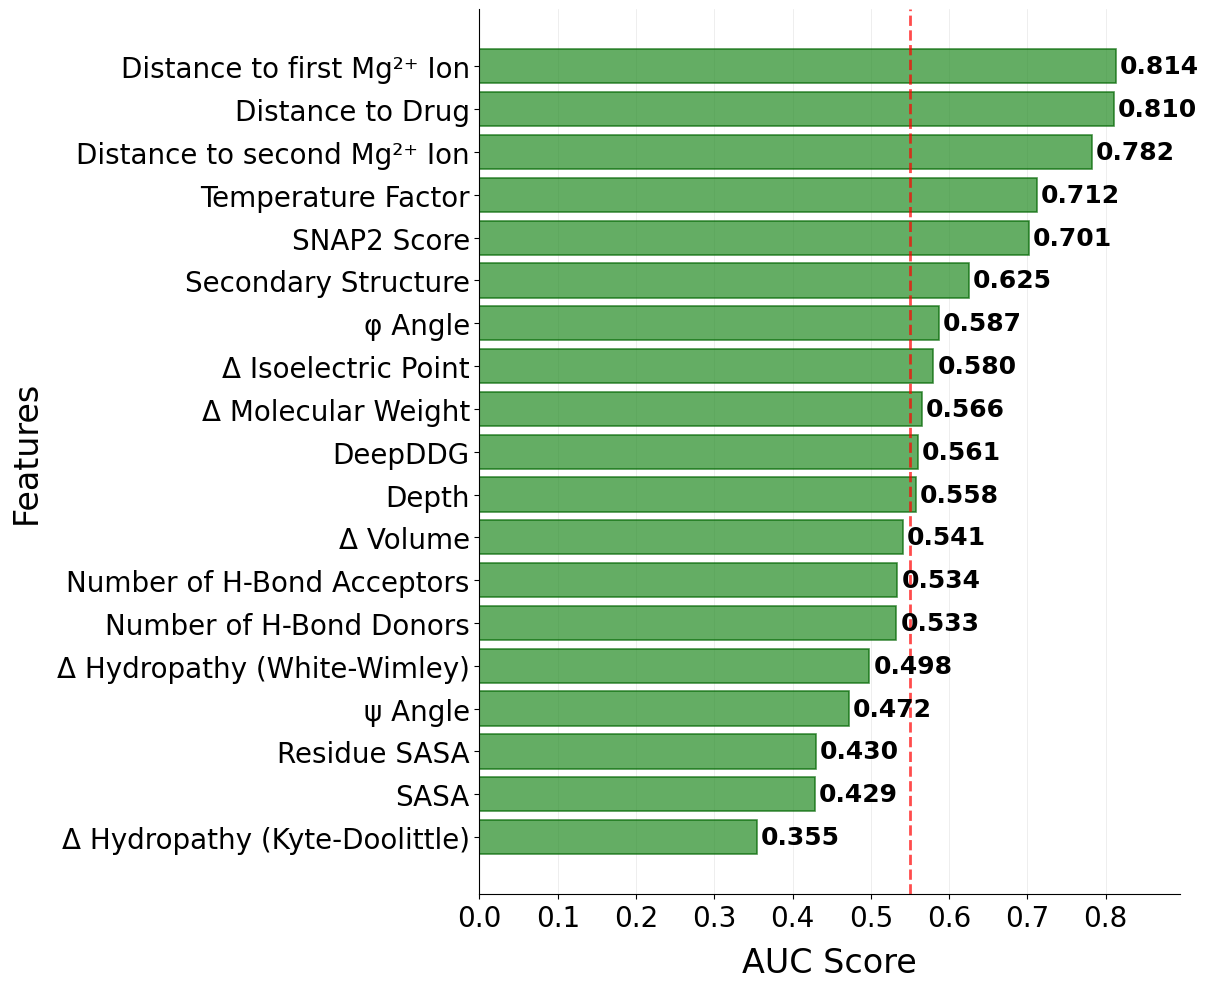

In [12]:
import matplotlib.pyplot as plt

# Create a more polished horizontal bar plot
fig, ax = plt.subplots(figsize=(12, 10))

# Create the bar plot with better styling
bars = ax.barh(df.feature, df.auc, color='forestgreen', alpha=0.7, edgecolor='darkgreen', linewidth=1.2)

# Customize the plot
ax.set_xlabel('AUC Score', fontsize=24, labelpad=10)
ax.set_ylabel('Features', fontsize=24, labelpad=10)
# ax.set_title('Individual Feature Performance (AUC Score)\nHigher values indicate better predictive power', 
#              fontsize=18, fontweight='bold', pad=20)

# Add AUC values as text labels on the bars
for i, (bar, auc_val) in enumerate(zip(bars, df.auc)):
    ax.text(auc_val + 0.005, bar.get_y() + bar.get_height()/2, 
            f'{auc_val:.3f}', va='center', ha='left', fontsize=18, fontweight='bold')

# Add a vertical line at AUC = 0.55 (performance threshold)
ax.axvline(x=0.55, color='red', linestyle='--', alpha=0.7, linewidth=2, label='Performance Threshold (AUC = 0.55)')

# Customize grid and spines
ax.grid(axis='x', alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)

# Set x-axis limits with some padding
ax.set_xlim(0, max(df.auc) * 1.1)

# Rotate y-axis labels for better readability
plt.yticks(rotation=0, fontsize=20)
plt.xticks(fontsize=20)

# Add legend
# ax.legend(loc='lower right', fontsize=15)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Save the plot as svg
plt.savefig('pdf/feature_selection_LEV.svg', format='svg', dpi=1200, bbox_inches='tight')

# Display the plot
plt.show()